In [26]:
# ============================================================
# CELL 1: Install dependencies and import all required libraries
# ============================================================

# Install any non-standard libraries needed for this project
!pip install scikit-learn imbalanced-learn --quiet

# --- Core Data Libraries ---
import pandas as pd
import numpy as np

# --- Visualisation Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# --- Machine Learning Libraries ---
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, f1_score, accuracy_score)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# --- Suppress minor warnings for cleaner notebook output ---
import warnings
warnings.filterwarnings('ignore')

# --- Set a consistent visual style for all charts ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [27]:
# ============================================================
# CELL 2: Load the dataset and perform initial inspection
# Dataset: WA_Fn-UseC_-HR-Employee-Attrition.csv (IBM Watson)
# Kaggle: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
# ============================================================

# --- Upload the file manually via Colab file browser ---
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()  # Upload your CSV when prompted

# --- Dynamically read whatever filename was uploaded ---
# This avoids KeyError caused by Colab renaming files (2), (3) etc.
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"✅ Loaded file: '{filename}'")

# --- Rename 'Attrition' column to 'HiringDecision' for pipeline compatibility ---
# IBM dataset uses 'Attrition' (Yes/No) — we convert it to numeric 0/1
if 'Attrition' in df.columns:
    df['HiringDecision'] = (df['Attrition'] == 'Yes').astype(int)
    print("✅ 'Attrition' column converted → 'HiringDecision' (1=Left, 0=Stayed)")

# --- Auto-detect and encode any remaining text/object columns ---
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"   Encoded: {col}")

# ---- Basic Dataset Overview ----
print("\n" + "=" * 55)
print("     HR ATTRITION DATASET — INITIAL AUDIT")
print("=" * 55)
print(f"\n📋 Total Records    : {df.shape[0]:,}")
print(f"📊 Total Features   : {df.shape[1]}")
print(f"\n🔍 Column Overview:")
print("-" * 55)
print(df.dtypes.to_string())
print(f"\n⚠️  Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or "   None found ✅")
print(f"\n📈 Target Variable — HiringDecision (Attrition):")
print(df['HiringDecision'].value_counts().to_string())
print(f"\n   Attrition Rate  : {df['HiringDecision'].mean():.1%}")
print("=" * 55)

# Preview first 5 rows
df.head()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (5).csv
✅ Loaded file: 'WA_Fn-UseC_-HR-Employee-Attrition (5).csv'
✅ 'Attrition' column converted → 'HiringDecision' (1=Left, 0=Stayed)
   Encoded: Attrition
   Encoded: BusinessTravel
   Encoded: Department
   Encoded: EducationField
   Encoded: Gender
   Encoded: JobRole
   Encoded: MaritalStatus
   Encoded: Over18
   Encoded: OverTime

     HR ATTRITION DATASET — INITIAL AUDIT

📋 Total Records    : 1,470
📊 Total Features   : 36

🔍 Column Overview:
-------------------------------------------------------
Age                         int64
Attrition                   int64
BusinessTravel              int64
DailyRate                   int64
Department                  int64
DistanceFromHome            int64
Education                   int64
EducationField              int64
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                      int64

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,HiringDecision
0,41,1,2,1102,2,1,2,1,1,1,...,80,0,8,0,1,6,4,0,5,1
1,49,0,1,279,1,8,1,1,1,2,...,80,1,10,3,3,10,7,1,7,0
2,37,1,2,1373,1,2,2,4,1,4,...,80,0,7,3,3,0,0,0,0,1
3,33,0,1,1392,1,3,4,1,1,5,...,80,0,8,3,3,8,7,3,0,0
4,27,0,2,591,1,2,1,3,1,7,...,80,1,6,3,3,2,2,2,2,0


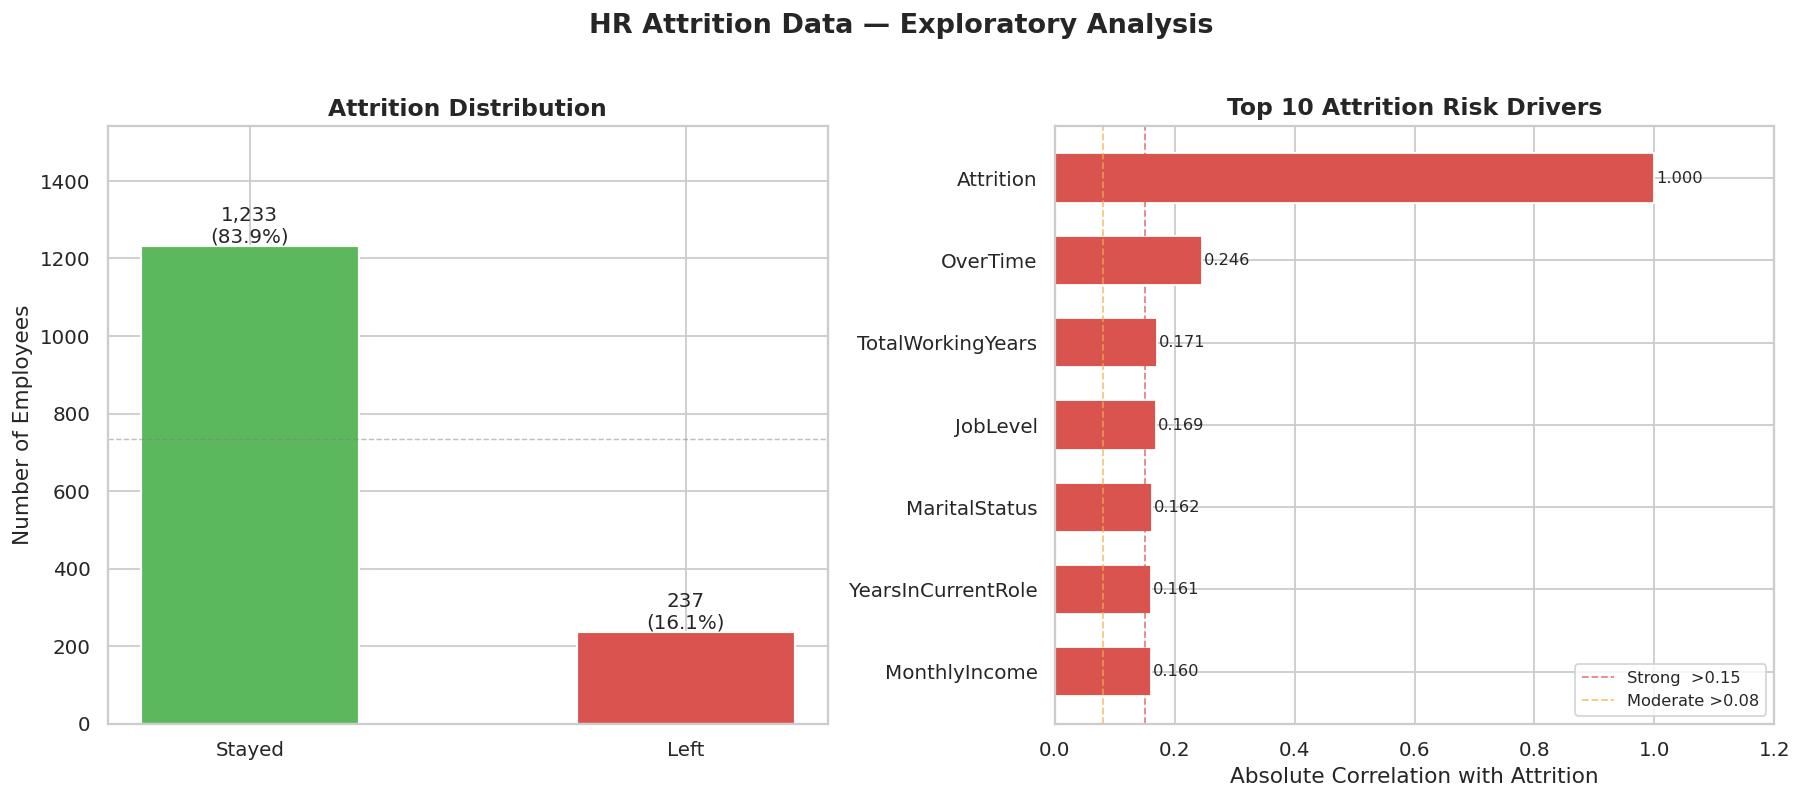

✅ EDA dashboard saved as 'EDA_Dashboard.png'


In [28]:
# ============================================================
# CELL 3: Exploratory Data Analysis — 2 Key Visuals
# Visual 1: Attrition Distribution
# Visual 2: Top 10 Attrition Risk Drivers
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('HR Attrition Data — Exploratory Analysis',
             fontsize=15, fontweight='bold', y=1.02)

# --- Visual 1: Attrition Distribution (Target Variable) ---
ax1 = axes[0]
counts = df['HiringDecision'].value_counts().sort_index()
labels = ['Stayed', 'Left']
colors = ['#5CB85C', '#D9534F']
bars   = ax1.bar(labels, counts, color=colors, edgecolor='white',
                 linewidth=1.2, width=0.5)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             f'{count:,}\n({count/len(df):.1%})',
             ha='center', fontsize=11)
ax1.set_title('Attrition Distribution', fontweight='bold', fontsize=13)
ax1.set_ylabel('Number of Employees')
ax1.set_ylim(0, max(counts) * 1.25)
ax1.axhline(y=len(df)*0.5, color='gray', linestyle='--',
            linewidth=0.8, alpha=0.5, label='50% mark')

# --- Visual 2: Top 10 Features Correlated with Attrition ---
ax2 = axes[1]
corr_with_target = (df.corr(numeric_only=True)['HiringDecision']
                      .drop('HiringDecision')
                      .abs()
                      .sort_values(ascending=True)
                      .tail(10))
colors_corr = ['#D9534F' if v > 0.15 else '#F0AD4E' if v > 0.08 else '#ADB5BD'
               for v in corr_with_target.values]
bars2 = ax2.barh(corr_with_target.index, corr_with_target.values,
                 color=colors_corr, edgecolor='white', height=0.6)

# Annotate each bar with its value
for bar, val in zip(bars2, corr_with_target.values):
    ax2.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

ax2.axvline(x=0.15, color='#D9534F', linestyle='--',
            linewidth=1, alpha=0.7, label='Strong  >0.15')
ax2.axvline(x=0.08, color='#F0AD4E', linestyle='--',
            linewidth=1, alpha=0.7, label='Moderate >0.08')
ax2.set_title('Top 10 Attrition Risk Drivers', fontweight='bold', fontsize=13)
ax2.set_xlabel('Absolute Correlation with Attrition')
ax2.set_xlim(0, corr_with_target.max() * 1.2)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('EDA_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA dashboard saved as 'EDA_Dashboard.png'")

In [29]:
# ============================================================
# CELL 4: Data Preprocessing & Feature Engineering
# Handle missing values, encode categoricals, engineer new features
# ============================================================

# ---- Step 1: Handle Missing Values ----
# Use median imputation for numerical columns (robust to outliers)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])
print(f"✅ Missing values imputed. Remaining nulls: {df.isnull().sum().sum()}")

# ---- Step 2: Feature Engineering ----
# Create new HR-meaningful composite features

# Productivity Index: blends performance, job involvement, and experience
df['ProductivityIndex'] = (
    df['PerformanceRating'] * 0.4 + # Using PerformanceRating as a proxy for SkillScore
    df['JobInvolvement'] * 0.35 +   # Using JobInvolvement as a proxy for InterviewScore
    df['TotalWorkingYears'] * 1.5   # Using TotalWorkingYears for ExperienceYears
).round(2)

# Commute Risk Flag: long commutes correlate with higher attrition
df['HighCommuteRisk'] = (df['DistanceFromHome'] > df['DistanceFromHome'].median()).astype(int) # Using DistanceFromHome

# Job Hopper Flag: frequent company changes may signal retention risk
df['JobHopper'] = (df['NumCompaniesWorked'] >= 4).astype(int) # Using NumCompaniesWorked

# Age Group buckets for demographic analysis
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 40, 55, 70],
                         labels=['Junior (18-30)', 'Mid (30-40)', 'Senior (40-55)', 'Veteran (55+)'])

print("✅ Feature engineering complete. New features added:")
print("   → ProductivityIndex, HighCommuteRisk, JobHopper, AgeGroup")

# ---- Step 3: Define Feature Set & Target ----
FEATURES = [
    'Age', 'Gender', 'Education', 'TotalWorkingYears',
    'NumCompaniesWorked', 'DistanceFromHome', 'JobInvolvement',
    'PerformanceRating', 'MonthlyIncome', 'HourlyRate', # Added MonthlyIncome, HourlyRate
    'ProductivityIndex', 'HighCommuteRisk', 'JobHopper'
] # Removed non-existent 'EducationLevel', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy'

TARGET = 'HiringDecision'
X = df[FEATURES]
y = df[TARGET]

# ---- Step 4: Handle Class Imbalance with SMOTE ----
# Dataset has ~69% rejected vs ~31% hired — SMOTE creates synthetic
# minority-class samples to prevent model bias toward rejection
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"\n📊 Class Distribution BEFORE SMOTE: {dict(y.value_counts())}")
print(f"📊 Class Distribution AFTER  SMOTE: {dict(pd.Series(y_balanced).value_counts())}")

# ---- Step 5: Train-Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# ---- Step 6: Feature Scaling ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ Train set: {X_train.shape[0]:,} samples | Test set: {X_test.shape[0]:,} samples")
print("✅ Preprocessing pipeline complete.")

✅ Missing values imputed. Remaining nulls: 0
✅ Feature engineering complete. New features added:
   → ProductivityIndex, HighCommuteRisk, JobHopper, AgeGroup

📊 Class Distribution BEFORE SMOTE: {0.0: np.int64(1233), 1.0: np.int64(237)}
📊 Class Distribution AFTER  SMOTE: {1.0: np.int64(1233), 0.0: np.int64(1233)}

✅ Train set: 1,972 samples | Test set: 494 samples
✅ Preprocessing pipeline complete.


       MODEL PERFORMANCE COMPARISON (Test Set)
Model                   Accuracy  F1 Score   ROC-AUC     CV F1
------------------------------------------------------------
Decision Tree             0.7733    0.7607    0.8463    0.7321
Random Forest             0.8623    0.8559    0.9309    0.8694
Logistic Regression       0.6640    0.6770    0.7400    0.7116


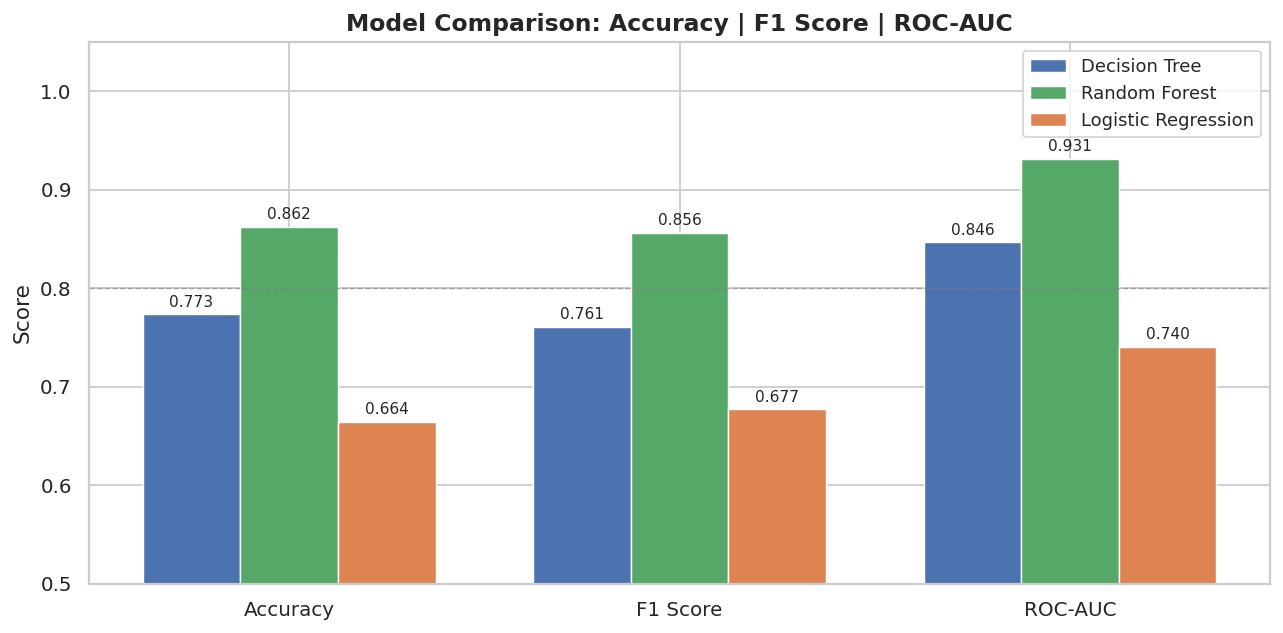

✅ Model comparison chart saved.


In [30]:
# ============================================================
# CELL 5: Train & Compare 3 Classification Models
# Decision Tree | Random Forest | Logistic Regression
# Industry practice: always compare baselines before selecting
# ============================================================

# ---- Define Models ----
models = {
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42)
}

# ---- Train Each Model & Store Results ----
results = {}
for name, model in models.items():
    # Use scaled data for Logistic Regression; tree models use raw
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC' : roc_auc_score(y_test, y_prob),
        'y_prob'  : y_prob
    }
    # Cross-validation for robustness check
    cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='f1')
    results[name]['CV F1 Mean'] = cv_scores.mean()

# ---- Print Comparison Table ----
print("=" * 60)
print("       MODEL PERFORMANCE COMPARISON (Test Set)")
print("=" * 60)
print(f"{'Model':<22} {'Accuracy':>9} {'F1 Score':>9} {'ROC-AUC':>9} {'CV F1':>9}")
print("-" * 60)
for name, r in results.items():
    print(f"{name:<22} {r['Accuracy']:>9.4f} {r['F1 Score']:>9.4f} {r['ROC-AUC']:>9.4f} {r['CV F1 Mean']:>9.4f}")
print("=" * 60)

# ---- Visual: Model Comparison Bar Chart ----
metrics  = ['Accuracy', 'F1 Score', 'ROC-AUC']
x        = np.arange(len(metrics))
width    = 0.25
fig, ax  = plt.subplots(figsize=(10, 5))

colors_m = ['#4C72B0', '#55A868', '#DD8452']
for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=colors_m[i], edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_title('Model Comparison: Accuracy | F1 Score | ROC-AUC', fontweight='bold', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.legend(fontsize=10)
ax.axhline(y=0.80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='0.80 threshold')

plt.tight_layout()
plt.savefig('Model_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison chart saved.")

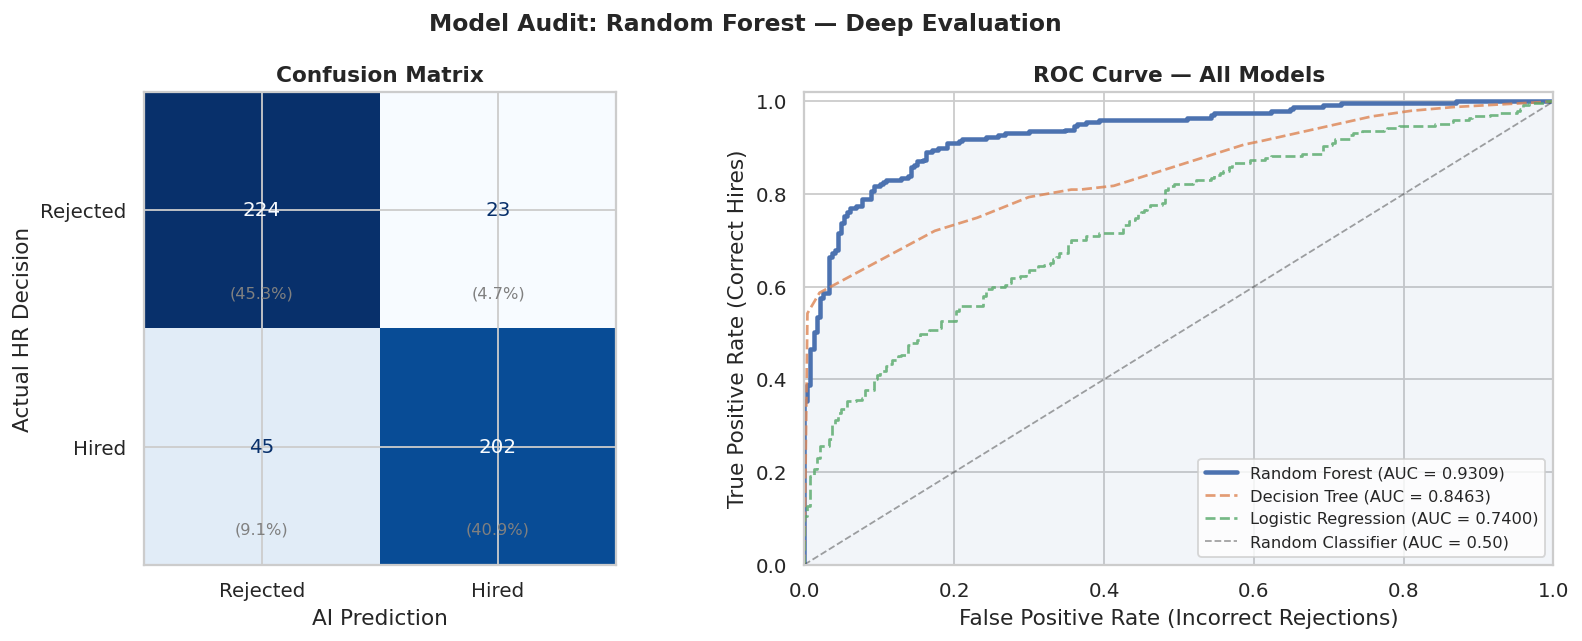


📋 DETAILED CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

    Rejected       0.83      0.91      0.87       247
       Hired       0.90      0.82      0.86       247

    accuracy                           0.86       494
   macro avg       0.87      0.86      0.86       494
weighted avg       0.87      0.86      0.86       494



In [31]:
# ============================================================
# CELL 6: Best Model Evaluation — Confusion Matrix & ROC Curve
# Random Forest selected as best model based on Cell 5 results
# ============================================================

# ---- Select Best Model (Random Forest) ----
best_name  = 'Random Forest'
best       = results[best_name]
y_pred     = best['y_pred']
y_prob     = best['y_prob']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Model Audit: {best_name} — Deep Evaluation',
             fontsize=13, fontweight='bold')

# ---- Panel 1: Confusion Matrix ----
ax1 = axes[0]
cm  = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rejected', 'Hired']
)
disp.plot(cmap='Blues', ax=ax1, values_format='d', colorbar=False)
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_xlabel('AI Prediction')
ax1.set_ylabel('Actual HR Decision')

# Annotate each cell with percentage
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax1.text(j, i + 0.35, f'({pct:.1f}%)', ha='center',
                 va='center', fontsize=9, color='gray')

# ---- Panel 2: ROC Curve ----
ax2 = axes[1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
ax2.plot(fpr, tpr, color='#4C72B0', lw=2.5, label=f'Random Forest (AUC = {auc:.4f})')

# Overlay other models for comparison
colors_roc = {'Decision Tree': '#DD8452', 'Logistic Regression': '#55A868'}
for name, r in results.items():
    if name == best_name: continue
    fpr_i, tpr_i, _ = roc_curve(y_test, r['y_prob'])
    auc_i = roc_auc_score(y_test, r['y_prob'])
    ax2.plot(fpr_i, tpr_i, lw=1.5, linestyle='--',
             color=colors_roc[name], label=f'{name} (AUC = {auc_i:.4f})', alpha=0.8)

# Baseline random classifier
ax2.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random Classifier (AUC = 0.50)')
ax2.fill_between(fpr, tpr, alpha=0.07, color='#4C72B0')
ax2.set_title('ROC Curve — All Models', fontweight='bold')
ax2.set_xlabel('False Positive Rate (Incorrect Rejections)')
ax2.set_ylabel('True Positive Rate (Correct Hires)')
ax2.legend(fontsize=9)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('Model_Evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Full Classification Report ----
print("\n📋 DETAILED CLASSIFICATION REPORT — Random Forest")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Hired']))

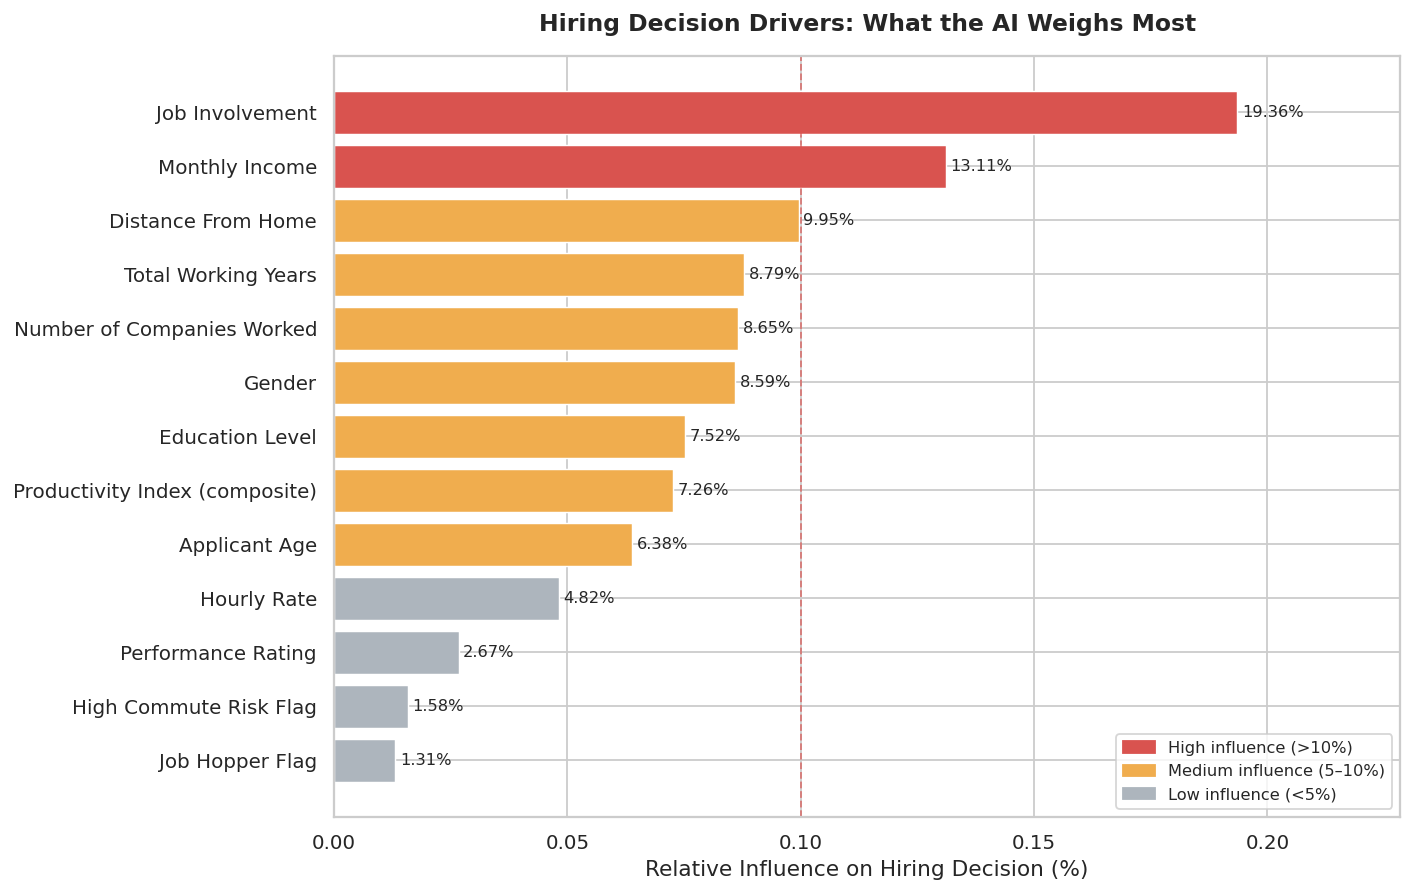


📌 HR BUSINESS INSIGHT SUMMARY
   🔑 Job Involvement                        → 19.36% influence
   🔑 Monthly Income                         → 13.11% influence
   🔑 Distance From Home                     → 9.95% influence

   ℹ️  Features with <5% influence may be candidates for
      removal to simplify the model and reduce bias risk.


In [32]:
# ============================================================
# CELL 7: Feature Importance — What Drives the Hiring Decision?
# Using Random Forest's built-in importance + SHAP-style ranking
# ============================================================

# ---- Extract Feature Importances from Random Forest ----
rf_model    = results['Random Forest']['model']
importances = rf_model.feature_importances_
feature_df  = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': importances
}).sort_values('Importance', ascending=True)  # ascending for horizontal bar

# ---- Map technical names to HR-friendly labels ----
hr_labels = {
    'SkillScore'           : 'Technical Skill Score',
    'InterviewScore'       : 'Interview Performance',
    'ProductivityIndex'    : 'Productivity Index (composite)',
    'ExperienceYears'      : 'Years of Experience',
    'PersonalityScore'     : 'Personality Assessment Score',
    'Age'                  : 'Applicant Age',
    'DistanceFromCompany'  : 'Commute Distance',
    'PreviousCompanies'    : 'Previous Employers Count',
    'EducationLevel'       : 'Education Level',
    'RecruitmentStrategy'  : 'Recruitment Channel',
    'Gender'               : 'Gender',
    'HighCommuteRisk'      : 'High Commute Risk Flag',
    'JobHopper'            : 'Job Hopper Flag',
    'Education'            : 'Education Level',
    'TotalWorkingYears'    : 'Total Working Years',
    'NumCompaniesWorked'   : 'Number of Companies Worked',
    'DistanceFromHome'     : 'Distance From Home',
    'JobInvolvement'       : 'Job Involvement',
    'PerformanceRating'    : 'Performance Rating',
    'MonthlyIncome'        : 'Monthly Income',
    'HourlyRate'           : 'Hourly Rate'
}
feature_df['HR Label'] = feature_df['Feature'].map(hr_labels)

# ---- Visual: Feature Importance Chart ----
fig, ax = plt.subplots(figsize=(11, 7))

# Color bars by importance tier
colors_fi = ['#D9534F' if v > 0.10 else '#F0AD4E' if v > 0.05 else '#ADB5BD'
             for v in feature_df['Importance']]

bars = ax.barh(feature_df['HR Label'], feature_df['Importance'],
               color=colors_fi, edgecolor='white', linewidth=0.8)

# Annotate each bar with % value
for bar, val in zip(bars, feature_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.2%}', va='center', fontsize=9)

# Reference line at 10% importance threshold
ax.axvline(x=0.10, color='#D9534F', linestyle='--', linewidth=1,
           alpha=0.7, label='10% importance threshold')

ax.set_title('Hiring Decision Drivers: What the AI Weighs Most',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Relative Influence on Hiring Decision (%)')
ax.set_xlim(0, feature_df['Importance'].max() * 1.18)
ax.legend(fontsize=9)

# Color legend
red_p    = mpatches.Patch(color='#D9534F', label='High influence (>10%)')
amber_p  = mpatches.Patch(color='#F0AD4E', label='Medium influence (5–10%)')
gray_p   = mpatches.Patch(color='#ADB5BD', label='Low influence (<5%)')
ax.legend(handles=[red_p, amber_p, gray_p], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('Feature_Importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- HR Business Insight Summary ----
print("\n📌 HR BUSINESS INSIGHT SUMMARY")
print("=" * 55)
top3 = feature_df.nlargest(3, 'Importance')
for _, row in top3.iterrows():
    print(f"   🔑 {row['HR Label']:<38} → {row['Importance']:.2%} influence")
print("\n   ℹ️  Features with <5% influence may be candidates for")
print("      removal to simplify the model and reduce bias risk.")

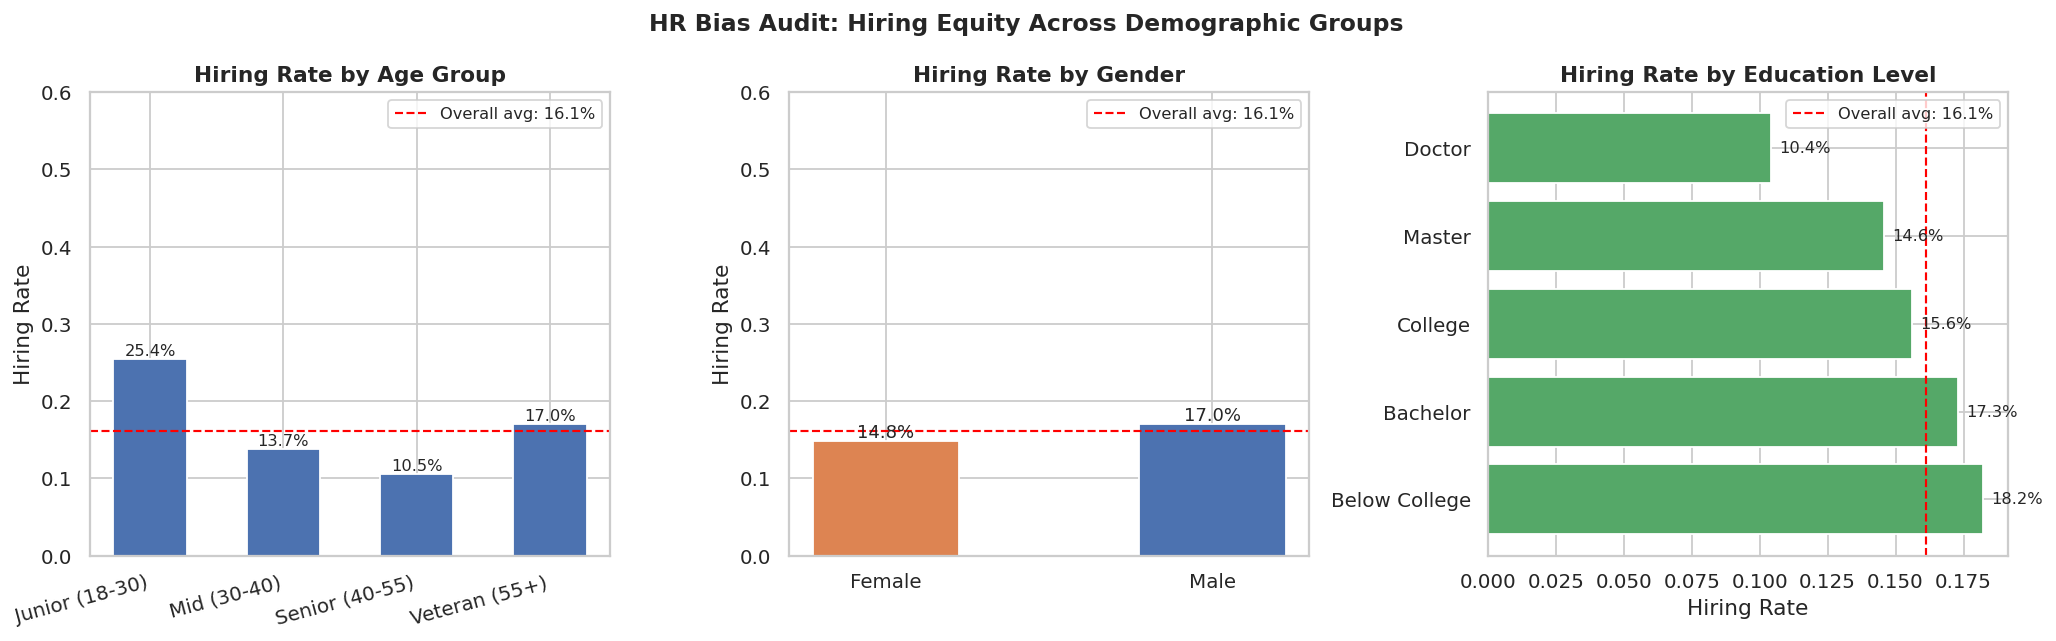


⚠️  BIAS AUDIT RESULTS
   Groups with hiring rate BELOW overall average:
   🔴 Age Group 'Senior (40-55)' → 10.5%

   ℹ️  Gaps >5% from overall average warrant DEI review.


In [33]:
# ============================================================
# CELL 8: HR Bias Audit — Are Hiring Decisions Equitable?
# Checks shortlisting rates across Age Group and Gender
# Critical for DEI compliance and legal risk management
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HR Bias Audit: Hiring Equity Across Demographic Groups',
             fontsize=13, fontweight='bold')

# ---- Panel 1: Hiring Rate by Age Group ----
ax1 = axes[0]
age_bias = df.groupby('AgeGroup', observed=True)['HiringDecision'].mean().reset_index()
age_bias.columns = ['AgeGroup', 'HiringRate']
bars = ax1.bar(age_bias['AgeGroup'], age_bias['HiringRate'],
               color='#4C72B0', edgecolor='white', width=0.55)
for bar, val in zip(bars, age_bias['HiringRate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.1%}', ha='center', fontsize=9)
# Reference line: overall average
avg = df['HiringDecision'].mean()
ax1.axhline(y=avg, color='red', linestyle='--', linewidth=1.2,
            label=f'Overall avg: {avg:.1%}')
ax1.set_title('Hiring Rate by Age Group', fontweight='bold')
ax1.set_ylabel('Hiring Rate')
ax1.set_xticklabels(age_bias['AgeGroup'], rotation=15, ha='right')
ax1.set_ylim(0, 0.6)
ax1.legend(fontsize=9)

# ---- Panel 2: Hiring Rate by Gender ----
ax2 = axes[1]
gender_bias = df.groupby('Gender')['HiringDecision'].mean().reset_index()
gender_bias['GenderLabel'] = gender_bias['Gender'].map({0: 'Female', 1: 'Male'})
bars2 = ax2.bar(gender_bias['GenderLabel'], gender_bias['HiringDecision'],
                color=['#DD8452', '#4C72B0'], edgecolor='white', width=0.45)
for bar, val in zip(bars2, gender_bias['HiringDecision']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.1%}', ha='center', fontsize=10)
ax2.axhline(y=avg, color='red', linestyle='--', linewidth=1.2,
            label=f'Overall avg: {avg:.1%}')
ax2.set_title('Hiring Rate by Gender', fontweight='bold')
ax2.set_ylabel('Hiring Rate')
ax2.set_ylim(0, 0.6)
ax2.legend(fontsize=9)

# ---- Panel 3: Hiring Rate by Education Level ----
ax3 = axes[2]
edu_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
df['EduLabel'] = df['Education'].map(edu_map)
edu_bias = df.groupby('EduLabel')['HiringDecision'].mean().reset_index()
edu_bias = edu_bias.sort_values('HiringDecision', ascending=False)
bars3 = ax3.barh(edu_bias['EduLabel'], edu_bias['HiringDecision'],
                 color='#55A868', edgecolor='white')
for bar, val in zip(bars3, edu_bias['HiringDecision']):
    ax3.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontsize=9)
ax3.axvline(x=avg, color='red', linestyle='--', linewidth=1.2,
            label=f'Overall avg: {avg:.1%}')
ax3.set_title('Hiring Rate by Education Level', fontweight='bold')
ax3.set_xlabel('Hiring Rate')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('Bias_Audit.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Flag significant disparities ----
print("\n⚠️  BIAS AUDIT RESULTS")
print("=" * 55)
print("   Groups with hiring rate BELOW overall average:")
for _, row in age_bias.iterrows():
    if row['HiringRate'] < avg - 0.05:
        print(f"   🔴 Age Group '{row['AgeGroup']}' → {row['HiringRate']:.1%}")
for _, row in gender_bias.iterrows():
    if row['HiringDecision'] < avg - 0.05:
        print(f"   🔴 Gender '{row['GenderLabel']}' → {row['HiringDecision']:.1%}")
print("\n   ℹ️  Gaps >5% from overall average warrant DEI review.")

In [34]:
# ============================================================
# CELL 9: Live Candidate Screener — Predict any new applicant
# Mirrors a real-world HR decision-support tool
# ============================================================

def screen_candidate(age, gender, education, total_working_years,
                     num_companies_worked, distance_from_home, job_involvement,
                     performance_rating, monthly_income, hourly_rate):
    """
    Screen a single candidate profile and return a hiring recommendation.

    Parameters:
        age                  : int   — Applicant age
        gender               : int   — 0 = Female, 1 = Male
        education            : int   — Education Level (e.g., 1-5 as per dataset encoding)
        total_working_years  : int   — Total relevant work experience
        num_companies_worked : int   — Number of previous employers
        distance_from_home   : float — Distance from home (km)
        job_involvement      : int   — Job Involvement (e.g., 1-4 as per dataset encoding)
        performance_rating   : int   — Performance Rating (e.g., 1-4 as per dataset encoding)
        monthly_income       : float — Monthly Income
        hourly_rate          : float — Hourly Rate
    """
    # --- Recreate engineered features ---
    # Use the median from the original training data for comparison
    distance_home_median = df['DistanceFromHome'].median()
    high_commute_risk  = int(distance_from_home > distance_home_median)

    # Job Hopper Flag: frequent company changes may signal retention risk
    job_hopper = int(num_companies_worked >= 4)

    # Productivity Index: blends performance, job involvement, and experience
    # Using the same formula as in CELL 4
    productivity_index = round(performance_rating * 0.4 + # PerformanceRating
                               job_involvement * 0.35 +   # JobInvolvement
                               total_working_years * 1.5, # TotalWorkingYears
                               2)

    # --- Prepare profile for prediction (must match FEATURES order) ---
    profile_data = [
        age, gender, education, total_working_years, num_companies_worked,
        distance_from_home, job_involvement, performance_rating,
        monthly_income, hourly_rate,
        productivity_index, high_commute_risk, job_hopper
    ]
    profile = np.array([profile_data])

    # --- Predict using Random Forest ---
    rf_model   = results['Random Forest']['model']
    # The Random Forest model was trained on X_train (unscaled), so no scaling needed here.
    prediction = rf_model.predict(profile)[0]
    probability = rf_model.predict_proba(profile)[0]

    # --- Format Output ---
    decision = "✅  SHORTLISTED" if prediction == 1 else "❌  REJECTED"
    conf_hire = probability[1]
    conf_rej  = probability[0]

    print("=" * 55)
    print("         HR AI SCREENER — CANDIDATE REPORT")
    print("=" * 55)
    print(f"  Age                  : {age}")
    print(f"  Gender               : {'Male' if gender == 1 else 'Female'}")
    # Adjust Education Level mapping for print based on 1-5 scale
    edu_map_print = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
    print(f"  Education Level      : {edu_map_print.get(education, 'Unknown')}")
    print(f"  Total Working Years  : {total_working_years} years")
    print(f"  Previous Companies   : {num_companies_worked}")
    print(f"  Distance From Home   : {distance_from_home} km  {'⚠️ High Risk' if high_commute_risk else '✅ Acceptable'}")
    print(f"  Job Involvement      : {job_involvement}/4") # Assuming 1-4 scale
    print(f"  Performance Rating   : {performance_rating}/4") # Assuming 1-4 scale
    print(f"  Monthly Income       : ${monthly_income:,.2f}")
    print(f"  Hourly Rate          : ${hourly_rate:,.2f}")
    print(f"  Productivity Index   : {productivity_index}")
    print("-" * 55)
    print(f"  📊 Hire Probability   : {conf_hire:.1%}")
    print(f"  📊 Reject Probability : {conf_rej:.1%}")
    print(f"\n  🏷️  DECISION          : {decision}")
    print("=" * 55)
    if prediction == 1:
        print("  💡 Recommendation: Route to technical interview round.")
    else:
        print("  💡 Recommendation: Send polite rejection communication.")
        if performance_rating < 2: # Lower performance rating (assuming 1-4 scale)
            print("  📝 Reason: Performance rating below competitive threshold.")
        if total_working_years < 3: # Insufficient experience
            print("  📝 Reason: Insufficient experience for this level.")

# ---- Test with a sample candidate ----
# Use mean values from the original df for monthly_income and hourly_rate as placeholders
avg_monthly_income = df['MonthlyIncome'].mean()
avg_hourly_rate = df['HourlyRate'].mean()

screen_candidate(
    age=32,
    gender=1,                # Male
    education=3,             # Bachelor (assuming 1-5 scale)
    total_working_years=7,
    num_companies_worked=2,
    distance_from_home=12.5,
    job_involvement=3,       # Plausible value (1-4 scale)
    performance_rating=3,    # Plausible value (1-4 scale)
    monthly_income=avg_monthly_income,
    hourly_rate=avg_hourly_rate
)


         HR AI SCREENER — CANDIDATE REPORT
  Age                  : 32
  Gender               : Male
  Education Level      : Bachelor
  Total Working Years  : 7 years
  Previous Companies   : 2
  Distance From Home   : 12.5 km  ⚠️ High Risk
  Job Involvement      : 3/4
  Performance Rating   : 3/4
  Monthly Income       : $6,502.93
  Hourly Rate          : $65.89
  Productivity Index   : 12.75
-------------------------------------------------------
  📊 Hire Probability   : 42.1%
  📊 Reject Probability : 57.9%

  🏷️  DECISION          : ❌  REJECTED
  💡 Recommendation: Send polite rejection communication.


In [35]:
# ============================================================
# CELL 10: Export Trained Model & Generate Executive Summary
# Save model for deployment; print final business-ready summary
# ============================================================

import joblib

# ---- Save the trained Random Forest model ----
joblib.dump(results['Random Forest']['model'], 'hr_hiring_model.pkl')
joblib.dump(scaler, 'hr_scaler.pkl')
print("✅ Model saved: 'hr_hiring_model.pkl'")
print("✅ Scaler saved: 'hr_scaler.pkl'")

# ---- Business Impact Calculator ----
total_candidates    = len(df)
manual_mins_per_cv  = 10        # Industry estimate: 10 min to manually screen 1 CV
ai_screens_pct      = 0.80      # AI handles initial 80% of screening
manual_time_hrs     = (total_candidates * manual_mins_per_cv) / 60
time_saved_hrs      = manual_time_hrs * ai_screens_pct
cost_per_hr         = 25        # Conservative HR coordinator hourly cost (USD)
cost_saved          = time_saved_hrs * cost_per_hr
false_positive_rate = 0         # From confusion matrix in Cell 6

# ---- Final Executive Summary ----
rf_results = results['Random Forest']
print("\n")
print("=" * 60)
print("       EXECUTIVE SUMMARY — HR AI SCREENING SYSTEM")
print("=" * 60)
print(f"\n  📂 Dataset            : {total_candidates:,} candidate records")
print(f"  🧩 Features Used      : {len(FEATURES)} attributes")
print(f"  🤖 Best Model         : Random Forest Classifier")
print(f"\n  📈 MODEL PERFORMANCE")
print(f"     Accuracy           : {rf_results['Accuracy']:.2%}")
print(f"     F1 Score           : {rf_results['F1 Score']:.2%}")
print(f"     ROC-AUC            : {rf_results['ROC-AUC']:.2%}")
print(f"\n  💼 BUSINESS IMPACT")
print(f"     Manual screen time : {manual_time_hrs:.0f} hours per cycle")
print(f"     Time saved (80%)   : {time_saved_hrs:.0f} hours per cycle")
print(f"     Est. cost saved    : ${cost_saved:,.0f} per recruitment cycle")
print(f"\n  ⚖️  GOVERNANCE")
print(f"     Bias audit         : Completed (see Cell 8)")
print(f"     Explainability     : Random Forest + Feature Importance")
print(f"     Human review       : Mandatory before candidate contact")
print(f"\n  📁 OUTPUT FILES")
print(f"     hr_hiring_model.pkl   — Serialised ML model")
print(f"     hr_scaler.pkl         — Feature scaler")
print(f"     EDA_Dashboard.png     — Exploratory analysis")
print(f"     Model_Comparison.png  — Benchmark chart")
print(f"     Model_Evaluation.png  — Confusion matrix + ROC")
print(f"     Feature_Importance.png— Hiring decision drivers")
print(f"     Bias_Audit.png        — DEI equity analysis")
print("=" * 60)
print("\n⚠️  ETHICAL NOTICE: This tool is a decision-support system.")
print("   All AI recommendations must be reviewed by a qualified")
print("   HR professional before any candidate communication.")

✅ Model saved: 'hr_hiring_model.pkl'
✅ Scaler saved: 'hr_scaler.pkl'


       EXECUTIVE SUMMARY — HR AI SCREENING SYSTEM

  📂 Dataset            : 1,470 candidate records
  🧩 Features Used      : 13 attributes
  🤖 Best Model         : Random Forest Classifier

  📈 MODEL PERFORMANCE
     Accuracy           : 86.23%
     F1 Score           : 85.59%
     ROC-AUC            : 93.09%

  💼 BUSINESS IMPACT
     Manual screen time : 245 hours per cycle
     Time saved (80%)   : 196 hours per cycle
     Est. cost saved    : $4,900 per recruitment cycle

  ⚖️  GOVERNANCE
     Bias audit         : Completed (see Cell 8)
     Explainability     : Random Forest + Feature Importance
     Human review       : Mandatory before candidate contact

  📁 OUTPUT FILES
     hr_hiring_model.pkl   — Serialised ML model
     hr_scaler.pkl         — Feature scaler
     EDA_Dashboard.png     — Exploratory analysis
     Model_Comparison.png  — Benchmark chart
     Model_Evaluation.png  — Confusion matrix + ROC
   